#  Cinema Audience Forecasting Challenge 

# **Name:** Abhijeet  
# **Roll:** 23f2004912  


In [1]:
import pandas as pd

df1 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
df2 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
df3 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')
df4 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
df5 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
df6 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
df7 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
df8 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')

dfs = [df1, df2, df3, df4, df5, df6, df7, df8]

for i, df in enumerate(dfs, 1):
    print(f"===== df{i} head =====")
    display(df.head())


===== df1 head =====


,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


===== df2 head =====


,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


===== df3 head =====


...

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


===== df7 head =====


,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


===== df8 head =====


,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


# IMPORT

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib.ticker as mticker
import seaborn as sns   
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 5)


# Exploratory Data Analysis

## Basic data types & Null Check

In [3]:
for name, df in [('df1',df1),('df2',df2),('df3',df3),('df4',df4),('df5',df5),('df6',df6),('df7',df7),('df8',df8)]:
    print(f'--- {name} ---')
    print(df.info())
    print(df.isnull().sum())


--- df1 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB
None
book_theater_id    0
cine_theater_id    0
dtype: int64
--- df2 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB
None
show_date      0
day_of_week    0
dtype: int64
--- df3 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              380

##  duplicates check

In [4]:
for name, df in [('df1',df1),('df2',df2),('df3',df3),('df4',df4),('df5',df5),('df6',df6),('df7',df7),('df8',df8)]:
    print(name, 'duplicates:', df.duplicated().sum())


df1 duplicates: 0
df2 duplicates: 0
df3 duplicates: 0
df4 duplicates: 354
df5 duplicates: 12541
df6 duplicates: 0
df7 duplicates: 10
df8 duplicates: 2042


## Overview target stats

In [5]:
display(df7['audience_count'].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
print("Zeros %:", (df7['audience_count']==0).mean())


count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
1%            2.000000
5%            6.000000
25%          18.000000
50%          34.000000
75%          58.000000
95%         102.000000
99%         144.000000
max        1350.000000
Name: audience_count, dtype: float64

Zeros %: 0.0


## Target Distribution (histogram + log1p)

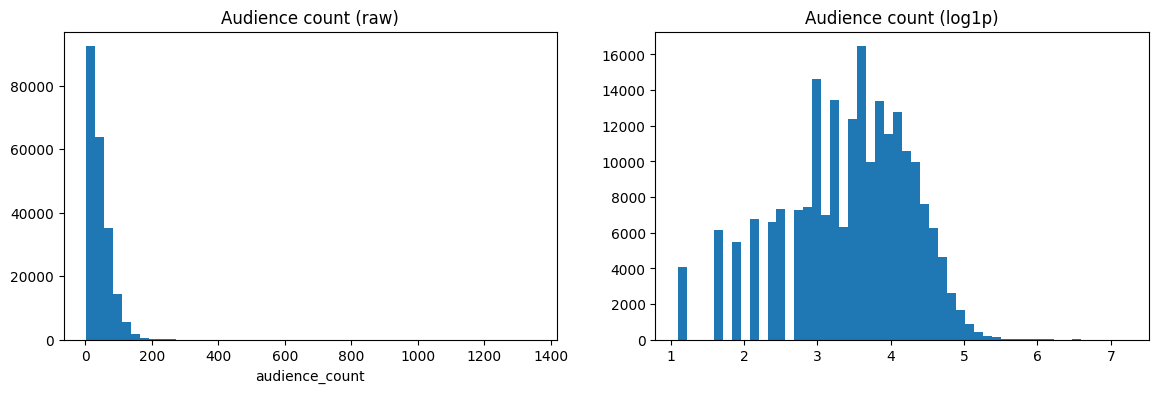

In [6]:
fig, axs = plt.subplots(1,2, figsize=(14,4))
axs[0].hist(df7['audience_count'].dropna(), bins=50)
axs[0].set_title('Audience count (raw)')
axs[0].set_xlabel('audience_count')
axs[1].hist(np.log1p(df7['audience_count'].clip(lower=0)), bins=50)
axs[1].set_title('Audience count (log1p)')
plt.show()

## Top / bottom theatres by average audience

In [7]:
theater_stats = df7.groupby('book_theater_id')['audience_count'].agg(['count','mean','median','std','sum']).reset_index().sort_values('mean', ascending=False)
display(theater_stats.head(10))
display(theater_stats.tail(10))

,book_theater_id,count,mean,median,std,sum
167,book_00169,197,127.543147,120.0,32.420301,25126
93,book_00095,113,127.132743,114.0,82.204830,14366
150,book_00152,25,108.880000,130.0,74.464936,2722
487,book_00490,182,105.000000,112.0,33.959189,19110
156,book_00158,167,101.113772,98.0,62.422812,16886
585,book_00589,334,98.449102,88.0,40.816613,32882
488,book_00491,79,94.506329,90.0,21.832623,7466
592,book_00596,46,93.478261,69.0,86.251760,4300
290,book_00292,187,93.465241,98.0,56.153138,17478
712,book_00716,155,93.200000,94.0,15.775371,14446


,book_theater_id,count,mean,median,std,sum
612,book_00616,224,9.294643,8.0,5.702864,2082
590,book_00594,213,9.051643,8.0,5.581486,1928
546,book_00550,359,8.969359,8.0,6.566944,3220
214,book_00216,161,8.795031,6.0,13.912727,1416
292,book_00294,211,8.672986,8.0,5.336503,1830
249,book_00251,183,7.956284,4.0,12.847296,1456
475,book_00478,173,7.861272,6.0,4.887496,1360
603,book_00607,122,6.754098,6.0,4.680382,824
786,book_00790,184,5.750000,2.0,8.774186,1058
406,book_00409,141,2.411348,2.0,1.647816,340


## Time coverage & missing dates per theatre

###  Global date range

In [8]:
global_min = df7['show_date'].min()
global_max = df7['show_date'].max()
print("Global date range:", global_min, "to", global_max)

Global date range: 2023-01-01 to 2024-02-28


## Per-theater date coverage (number of unique dates)

df7.show_date dtype before: object
df7.show_date dtype after: datetime64[ns]
Number of unparsable dates (NaT): 0
Least covered theatres (coverage_ratio ascending):


,book_theater_id,min,max,nunique,span_days,coverage_ratio
521,book_00524,2023-07-06,2023-08-24,2,50,0.040000
120,book_00122,2023-01-27,2024-02-28,49,398,0.123116
404,book_00407,2023-07-02,2024-02-25,32,239,0.133891
592,book_00596,2023-07-03,2024-02-12,46,225,0.204444
379,book_00382,2023-07-03,2024-02-26,55,239,0.230126
801,book_00805,2023-07-17,2024-02-28,61,227,0.268722
93,book_00095,2023-02-18,2024-02-28,113,376,0.300532
538,book_00542,2023-07-05,2024-02-28,81,239,0.338912
803,book_00807,2023-07-03,2024-02-27,86,240,0.358333
760,book_00764,2023-07-06,2024-02-28,92,238,0.386555



Most covered theatres (coverage_ratio descending):


,book_theater_id,min,max,nunique,span_days,coverage_ratio
179,book_00181,2023-07-01,2024-02-28,243,243,1.0
365,book_00368,2024-02-01,2024-02-28,28,28,1.0
596,book_00600,2023-07-01,2024-02-28,243,243,1.0
598,book_00602,2023-07-01,2024-02-28,243,243,1.0
4,book_00005,2023-07-01,2024-02-28,243,243,1.0
375,book_00378,2023-07-01,2024-02-28,243,243,1.0
518,book_00521,2023-11-25,2024-02-28,96,96,1.0
503,book_00506,2024-01-30,2024-02-28,30,30,1.0
297,book_00299,2023-07-01,2024-02-28,243,243,1.0
103,book_00105,2024-02-15,2024-02-15,1,1,1.0


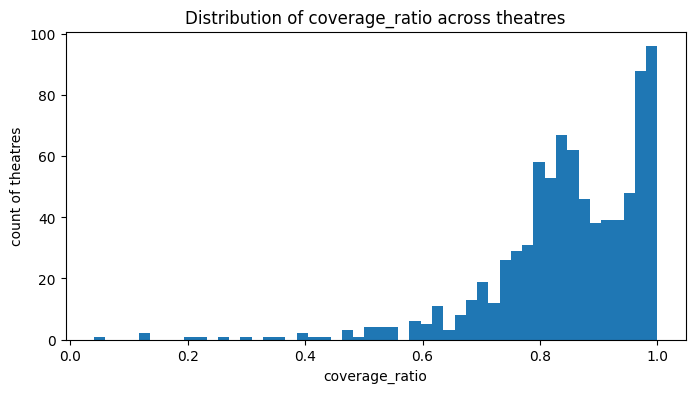

In [9]:
import pandas as pd
print("df7.show_date dtype before:", df7['show_date'].dtype)

if not pd.api.types.is_datetime64_any_dtype(df7['show_date']):
    df7['show_date'] = pd.to_datetime(df7['show_date'], errors='coerce')  # invalid parse -> NaT

print("df7.show_date dtype after:", df7['show_date'].dtype)
print("Number of unparsable dates (NaT):", df7['show_date'].isna().sum())

if df7['show_date'].isna().any():
    print("Warning: there are rows with missing show_date — they will be excluded from coverage calculation.")

coverage = df7.dropna(subset=['show_date']).groupby('book_theater_id')['show_date'].agg(['min','max','nunique']).reset_index()
coverage['span_days'] = (coverage['max'] - coverage['min']).dt.days + 1
coverage['coverage_ratio'] = coverage['nunique'] / coverage['span_days']

print("Least covered theatres (coverage_ratio ascending):")
display(coverage.sort_values('coverage_ratio').head(10))

print("\nMost covered theatres (coverage_ratio descending):")
display(coverage.sort_values('coverage_ratio', ascending=False).head(10))


import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(coverage['coverage_ratio'].fillna(0), bins=50)
plt.title('Distribution of coverage_ratio across theatres')
plt.xlabel('coverage_ratio')
plt.ylabel('count of theatres')
plt.show()


## Seasonality and Weekends trend

,day_of_week,mean,median,count
0,Monday,47.623494,38.0,26305
1,Tuesday,35.039099,28.0,27264
2,Wednesday,35.220707,28.0,30656
3,Thursday,37.992760,32.0,30940
4,Friday,37.626460,30.0,31927
5,Saturday,45.244812,38.0,33875
6,Sunday,51.713413,44.0,33079


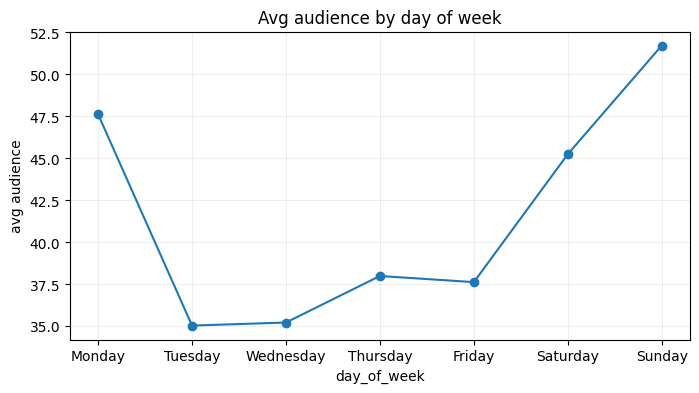

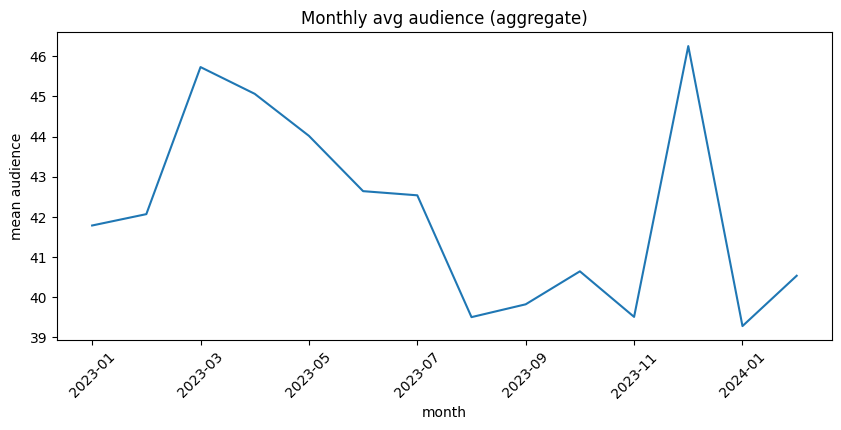

In [10]:
if not pd.api.types.is_datetime64_any_dtype(df2['show_date']):
    df2['show_date'] = pd.to_datetime(df2['show_date'], errors='coerce')

df7 = df7.merge(
    df2[['show_date', 'day_of_week']].drop_duplicates(),
    on='show_date',
    how='left'
)

dow = (
    df7.groupby('day_of_week')['audience_count']
    .agg(['mean', 'median', 'count'])
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)

display(dow)

plt.figure(figsize=(8,4))
plt.plot(dow['day_of_week'], dow['mean'], marker='o')
plt.title('Avg audience by day of week')
plt.ylabel('avg audience')
plt.xlabel('day_of_week')
plt.grid(alpha=0.2)
plt.show()

# --- 5) Monthly analysis ---
df7['month'] = df7['show_date'].dt.to_period('M').astype(str)

monthly = df7.groupby('month')['audience_count'].mean()

plt.figure(figsize=(10,4))
monthly.plot(title='Monthly avg audience (aggregate)', ylabel='mean audience')
plt.xticks(rotation=45)
plt.show()


## Theater MetaData Analysis

,theater_type,mean,median,count
0,Action,47.242530,40.0,5756
1,Comedy,47.012019,42.0,6573
2,Other,43.716841,34.0,44618
3,Drama,43.627634,36.0,23203


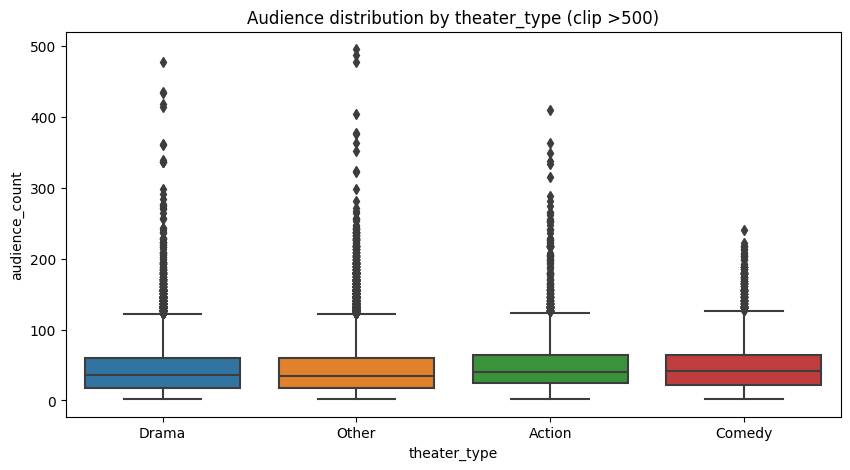

In [11]:

df7 = df7.merge(df4[['book_theater_id','theater_type','theater_area','latitude','longitude']], on='book_theater_id', how='left')

by_type = df7.groupby('theater_type')['audience_count'].agg(['mean','median','count']).sort_values('mean',ascending=False).reset_index()
display(by_type)

# Boxplot per theater_type
plt.figure(figsize=(10,5))
sns.boxplot(x='theater_type', y='audience_count', data=df7[df7['audience_count']<=500])  # clip extreme values for readability
plt.title('Audience distribution by theater_type (clip >500)')
plt.show()


# Advanced EDA

## offline ticket sales ( CinePOS )

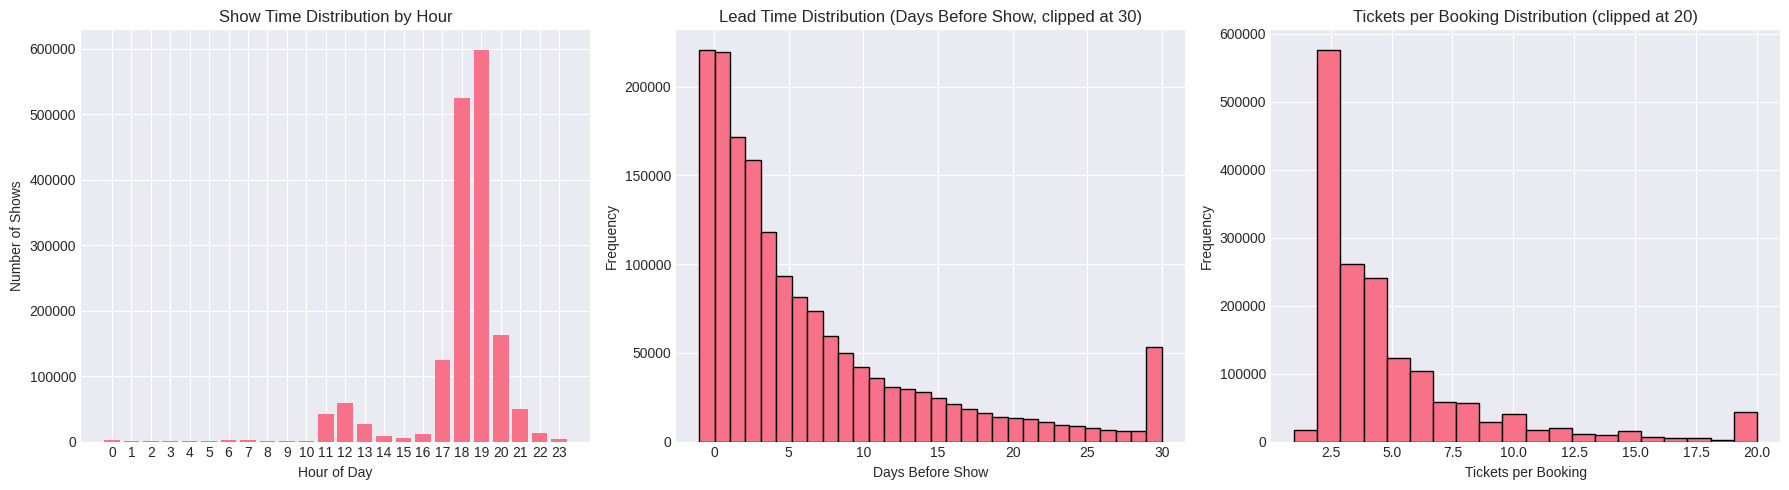


 CinePOS Booking Statistics (Offline):
• Total bookings: 1,641,966
• Total tickets sold: 8,189,051
• Average tickets per booking: 4.99
• Unique theaters: 13161
• Peak show hour: 19:00
• Peak booking hour: 21:00


In [12]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

df4 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
df5 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
df6 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
df7 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
df8 = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')

if 'show_datetime' in df5.columns:
    df5['show_datetime'] = pd.to_datetime(df5['show_datetime'], errors='coerce')
else:
    raise KeyError("df5 missing required column: 'show_datetime'")

if 'booking_datetime' in df5.columns:
    df5['booking_datetime'] = pd.to_datetime(df5['booking_datetime'], errors='coerce')
else:
    raise KeyError("df5 missing required column: 'booking_datetime'")

df5['show_date'] = df5['show_datetime'].dt.date
df5['show_hour'] = df5['show_datetime'].dt.hour
df5['booking_hour'] = df5['booking_datetime'].dt.hour
df5['lead_time_days'] = (df5['show_datetime'] - df5['booking_datetime']).dt.days
df5['lead_time_hours'] = (df5['show_datetime'] - df5['booking_datetime']).dt.total_seconds() / 3600

if 'tickets_sold' not in df5.columns:
    raise KeyError("df5 missing required column: 'tickets_sold'")
df5['tickets_sold'] = pd.to_numeric(df5['tickets_sold'], errors='coerce').fillna(0).astype(int)

show_hour_full = pd.Series(0, index=range(24))
show_hour_counts = df5['show_hour'].value_counts().sort_index()
show_hour_counts = show_hour_full.add(show_hour_counts, fill_value=0).astype(int)

booking_hour_counts = df5['booking_hour'].value_counts().sort_index()

lead_time_clipped = df5['lead_time_days'].clip(lower=df5['lead_time_days'].min(), upper=30).dropna()
tickets_clipped = df5['tickets_sold'].clip(upper=20)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(show_hour_counts.index, show_hour_counts.values)
axes[0].set_title('Show Time Distribution by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Shows')
axes[0].set_xticks(range(0, 24))
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(lead_time_clipped, bins=30, edgecolor='black')
axes[1].set_title('Lead Time Distribution (Days Before Show, clipped at 30)')
axes[1].set_xlabel('Days Before Show')
axes[1].set_ylabel('Frequency')

axes[2].hist(tickets_clipped, bins=20, edgecolor='black')
axes[2].set_title('Tickets per Booking Distribution (clipped at 20)')
axes[2].set_xlabel('Tickets per Booking')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n CinePOS Booking Statistics (Offline):")
print(f"• Total bookings: {len(df5):,}")
print(f"• Total tickets sold: {df5['tickets_sold'].sum():,}")
print(f"• Average tickets per booking: {df5['tickets_sold'].mean():.2f}")
if 'cine_theater_id' in df5.columns:
    print(f"• Unique theaters: {df5['cine_theater_id'].nunique()}")
else:
    print("• Unique theaters: column 'cine_theater_id' not found")
print(f"• Peak show hour: {int(show_hour_counts.idxmax()) if not show_hour_counts.empty else 'N/A'}:00")
print(f"• Peak booking hour: {int(booking_hour_counts.idxmax()) if not booking_hour_counts.empty else 'N/A'}:00")


## Online ticket Booking ( BookNow) 

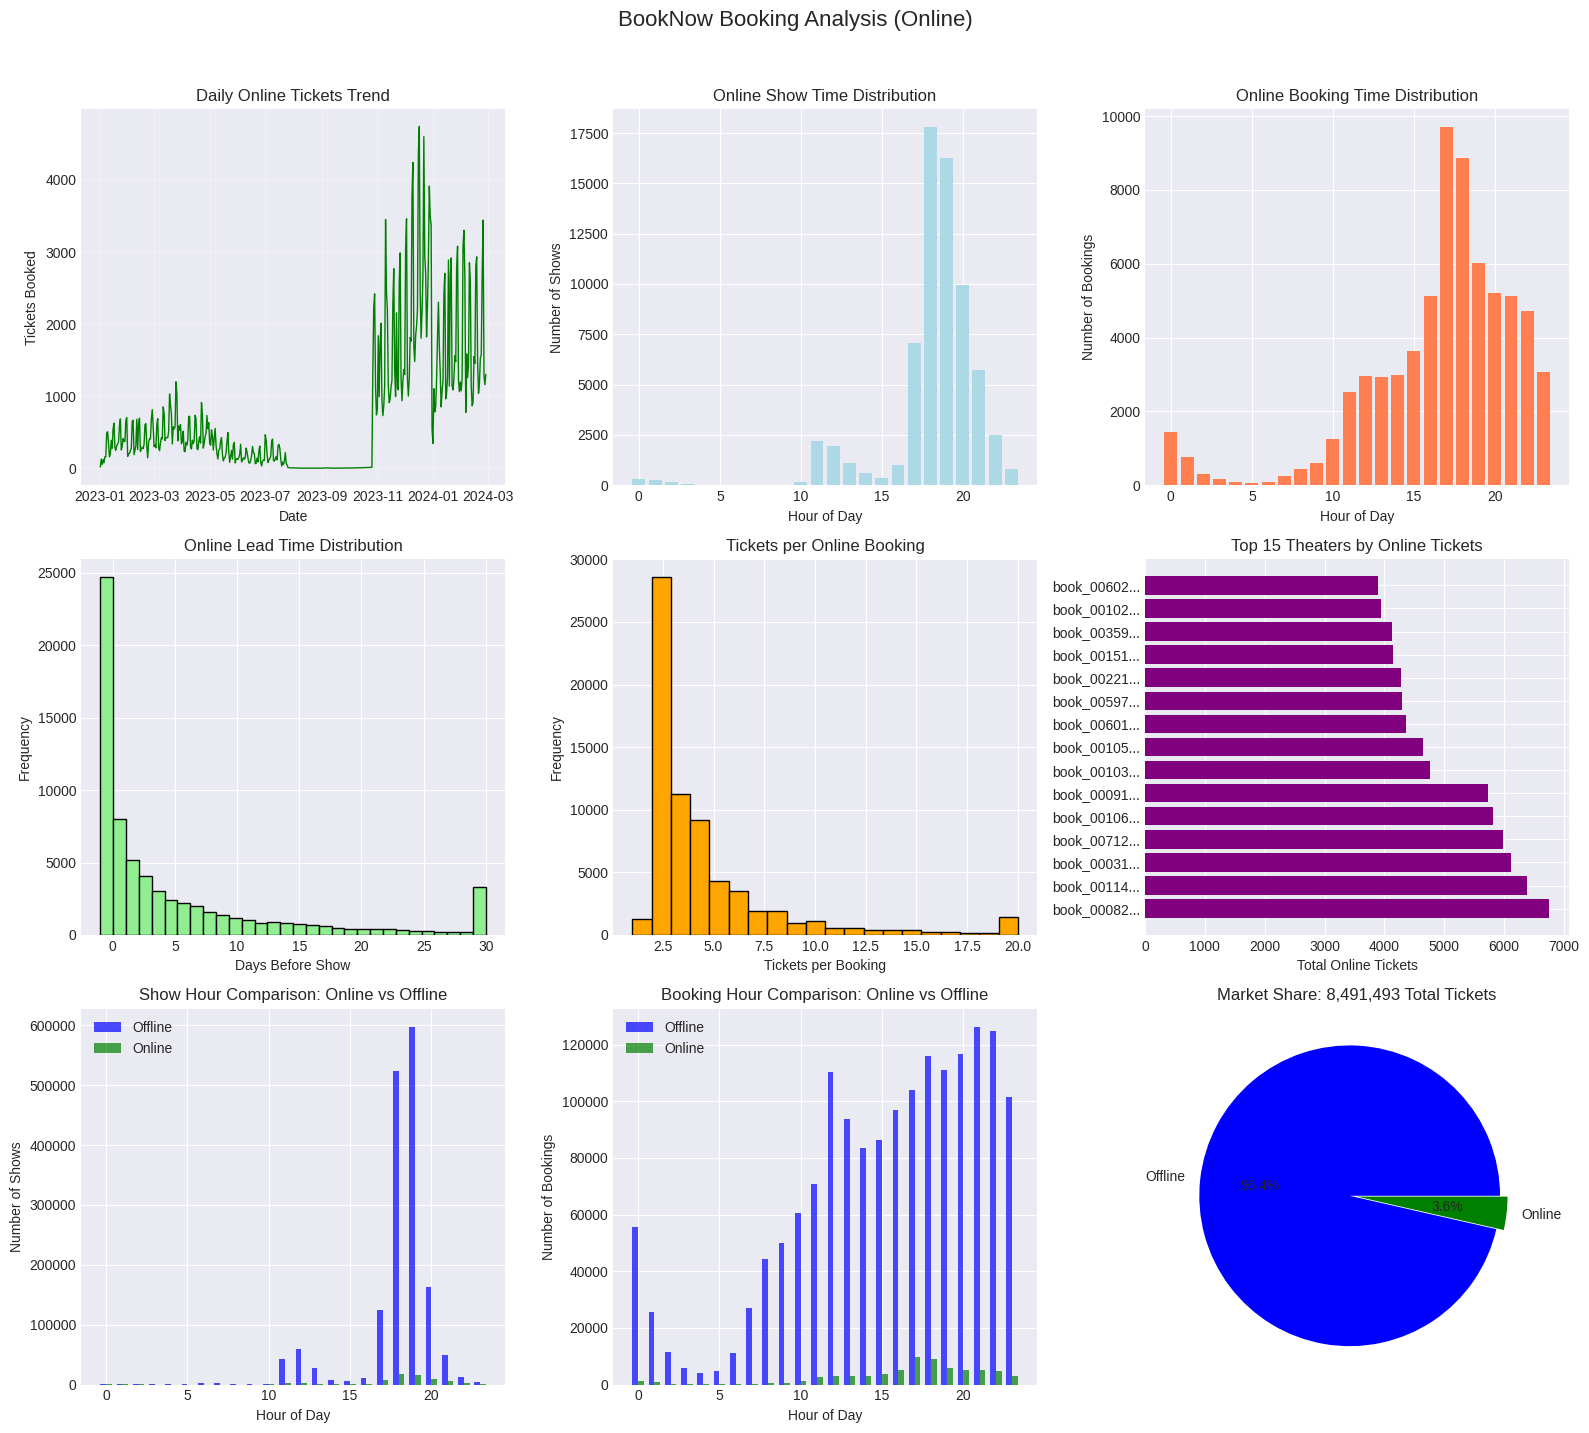

• Total online bookings: 68,336
• Total tickets booked online: 302,442


In [13]:

df8['show_datetime'] = pd.to_datetime(df8['show_datetime'])
df8['booking_datetime'] = pd.to_datetime(df8['booking_datetime'])

df8['show_date'] = df8['show_datetime'].dt.date
df8['show_hour'] = df8['show_datetime'].dt.hour
df8['booking_hour'] = df8['booking_datetime'].dt.hour
df8['lead_time_days'] = (df8['show_datetime'] - df8['booking_datetime']).dt.days
df8['lead_time_hours'] = (df8['show_datetime'] - df8['booking_datetime']).dt.total_seconds() / 3600

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('BookNow Booking Analysis (Online)', fontsize=16, y=1.02)

# Daily online tickets
daily_online = df8.groupby(pd.to_datetime(df8['show_date']))['tickets_booked'].sum()
axes[0,0].plot(daily_online.index, daily_online.values, color='green', linewidth=1)
axes[0,0].set_title('Daily Online Tickets Trend')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Tickets Booked')
axes[0,0].grid(True, alpha=0.3)

# Show hour distribution
show_hour_counts = df8['show_hour'].value_counts().sort_index()
axes[0,1].bar(show_hour_counts.index, show_hour_counts.values, color='lightblue')
axes[0,1].set_title('Online Show Time Distribution')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Number of Shows')

# Booking hour distribution
booking_hour_counts = df8['booking_hour'].value_counts().sort_index()
axes[0,2].bar(booking_hour_counts.index, booking_hour_counts.values, color='coral')
axes[0,2].set_title('Online Booking Time Distribution')
axes[0,2].set_xlabel('Hour of Day')
axes[0,2].set_ylabel('Number of Bookings')

# Lead time distribution
lead_time_clipped = df8['lead_time_days'].clip(upper=30)
axes[1,0].hist(lead_time_clipped, bins=30, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Online Lead Time Distribution')
axes[1,0].set_xlabel('Days Before Show')
axes[1,0].set_ylabel('Frequency')

# Tickets per online booking
tickets_clipped = df8['tickets_booked'].clip(upper=20)
axes[1,1].hist(tickets_clipped, bins=20, color='orange', edgecolor='black')
axes[1,1].set_title('Tickets per Online Booking')
axes[1,1].set_xlabel('Tickets per Booking')
axes[1,1].set_ylabel('Frequency')

# Top online theaters
top_online = df8.groupby('book_theater_id')['tickets_booked'].sum().nlargest(15)
axes[1,2].barh(range(len(top_online)), top_online.values, color='purple')
axes[1,2].set_yticks(range(len(top_online)))
axes[1,2].set_yticklabels([id[:12] + '...' for id in top_online.index])
axes[1,2].set_title('Top 15 Theaters by Online Tickets')
axes[1,2].set_xlabel('Total Online Tickets')

# Comparison: Online vs Offline show hours
cine_show_hours = df5['show_hour'].value_counts().sort_index()
book_show_hours = df8['show_hour'].value_counts().sort_index()

x = np.arange(24)
width = 0.35
axes[2,0].bar(x - width/2, cine_show_hours.reindex(range(24), fill_value=0), 
              width, label='Offline', color='blue', alpha=0.7)
axes[2,0].bar(x + width/2, book_show_hours.reindex(range(24), fill_value=0), 
              width, label='Online', color='green', alpha=0.7)
axes[2,0].set_title('Show Hour Comparison: Online vs Offline')
axes[2,0].set_xlabel('Hour of Day')
axes[2,0].set_ylabel('Number of Shows')
axes[2,0].legend()

# Comparison: Online vs Offline booking hours
cine_book_hours = df5['booking_hour'].value_counts().sort_index()
book_book_hours = df8['booking_hour'].value_counts().sort_index()

axes[2,1].bar(x - width/2, cine_book_hours.reindex(range(24), fill_value=0), 
              width, label='Offline', color='blue', alpha=0.7)
axes[2,1].bar(x + width/2, book_book_hours.reindex(range(24), fill_value=0), 
              width, label='Online', color='green', alpha=0.7)
axes[2,1].set_title('Booking Hour Comparison: Online vs Offline')
axes[2,1].set_xlabel('Hour of Day')
axes[2,1].set_ylabel('Number of Bookings')
axes[2,1].legend()

# Market share pie chart
total_offline = df5['tickets_sold'].sum()
total_online = df8['tickets_booked'].sum()
total = total_offline + total_online

axes[2,2].pie([total_offline, total_online], 
              labels=['Offline', 'Online'], 
              autopct='%1.1f%%', colors=['blue', 'green'],
              explode=(0.05, 0))
axes[2,2].set_title(f'Market Share: {total:,} Total Tickets')

plt.tight_layout()
plt.show()

print(f"• Total online bookings: {len(df8):,}")
print(f"• Total tickets booked online: {df8['tickets_booked'].sum():,}")


1. COUPLE BOOKINGS (2 tickets):
   • Online:  41.8% of bookings
   • Offline: 35.1% of bookings
   • Online has 1.2x more couple bookings!

2. FAMILY BOOKINGS (5+ tickets):
   • Online:  26.5% of bookings
   • Offline: 33.4% of bookings
   • Offline has more family bookings

3. SINGLE TICKETS (1 ticket):
   • Online:  1.8% of bookings
   • Offline: 1.0% of bookings
   • Online has more individual bookings

4. AVERAGE GROUP SIZE:
   • Online:  4.43 tickets
   • Offline: 4.99 tickets
   • Online groups are 0.9x larger on average

5. BOOKING TIME PREFERENCES:
   • Online peak: 17:00
   • Offline peak: 21:00
   • Largest groups book during: Evening (17-21)



# IMPORT for training and evaluation Data Loading

In [14]:
import numpy as np
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostRegressor, Pool
CATBOOST_AVAILABLE = True


# Data Loading

In [15]:
DATA_PATH = "/kaggle/input/Cinema_Audience_Forecasting_challenge/"

historical_visits = pd.read_csv(DATA_PATH + "booknow_visits/booknow_visits.csv")
theater_info = pd.read_csv(DATA_PATH + "booknow_theaters/booknow_theaters.csv")
date_info = pd.read_csv(DATA_PATH + "date_info/date_info.csv")
submission_format = pd.read_csv(DATA_PATH + "sample_submission/sample_submission.csv")

for dataset in [historical_visits, theater_info, date_info, submission_format]:
    dataset.columns = dataset.columns.str.strip()
    
historical_visits['show_date'] = pd.to_datetime(historical_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])

print(f"   • Historical visits: {historical_visits.shape}")
print(f"   • Theater info: {theater_info.shape}")
print(f"   • Date info: {date_info.shape}")
print(f"   • Submission: {submission_format.shape}")
    

   • Historical visits: (214046, 3)
   • Theater info: (829, 5)
   • Date info: (547, 2)
   • Submission: (38062, 2)


# Merging and Preprocessing Data

In [16]:
combined_data = historical_visits.merge(theater_info, on='book_theater_id', how='left')
combined_data = combined_data.merge(date_info, on='show_date', how='left')

for col in combined_data.columns:
    if combined_data[col].dtype in ['int64', 'float64']:
        combined_data[col] = combined_data[col].fillna(combined_data[col].median())
    elif combined_data[col].dtype == 'object':
        combined_data[col] = combined_data[col].fillna('Unknown')

Q1 = combined_data['audience_count'].quantile(0.25)
Q3 = combined_data['audience_count'].quantile(0.75)
IQR = Q3 - Q1
combined_data['audience_count'] = combined_data['audience_count'].clip(
    Q1 - 1.5*IQR, Q3 + 1.5*IQR
)

print(f" Data preprocessed. Shape: {combined_data.shape}")

 Data preprocessed. Shape: (214046, 8)


# Feature Engineering

In [17]:
# Time features
combined_data['day_of_week'] = combined_data['show_date'].dt.dayofweek
combined_data['month'] = combined_data['show_date'].dt.month
combined_data['day_of_year'] = combined_data['show_date'].dt.dayofyear
combined_data['week_of_year'] = combined_data['show_date'].dt.isocalendar().week
combined_data['is_weekend'] = (combined_data['day_of_week'] >= 5).astype(int)

# Cyclical features
combined_data['month_sin'] = np.sin(2 * np.pi * combined_data['month']/12)
combined_data['month_cos'] = np.cos(2 * np.pi * combined_data['month']/12)
combined_data['dow_sin'] = np.sin(2 * np.pi * combined_data['day_of_week']/7)
combined_data['dow_cos'] = np.cos(2 * np.pi * combined_data['day_of_week']/7)

# Theater statistics
theater_stats = combined_data.groupby('book_theater_id')['audience_count'].agg([
    'mean', 'std', 'median', 'min', 'max'
]).add_prefix('theater_').reset_index()
combined_data = combined_data.merge(theater_stats, on='book_theater_id', how='left')

# Lag features
combined_data = combined_data.sort_values(['book_theater_id', 'show_date'])
for lag in [1, 7, 14, 30]:
    combined_data[f'lag_{lag}'] = combined_data.groupby('book_theater_id')['audience_count'].shift(lag)

# Rolling statistics
for window in [7, 14, 30]:
    combined_data[f'rolling_mean_{window}'] = combined_data.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

# Fill NaN
for col in combined_data.columns:
    if col.startswith(('lag_', 'rolling_', 'theater_')):
        if combined_data[col].dtype in ['float64', 'int64']:
            combined_data[col] = combined_data[col].fillna(combined_data[col].median())

print(f" Feature engineering completed. Total features: {len(combined_data.columns)}")

 Feature engineering completed. Total features: 28


# feature Encoding

In [18]:
numerical_features = [
    'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'theater_mean', 'theater_std',
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14'
]

categorical_features = []
if 'theater_type' in combined_data.columns:
    categorical_features.append('theater_type')
if 'theater_area' in combined_data.columns:
    categorical_features.append('theater_area')

# Filter to available features
numerical_features = [f for f in numerical_features if f in combined_data.columns]
categorical_features = [f for f in categorical_features if f in combined_data.columns]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

X = combined_data[numerical_features + categorical_features].copy()
y = combined_data['audience_count'].values

if CATBOOST_AVAILABLE:
    X_catboost = X.copy()
    # CatBoost handles categorical features automatically
    cat_features_indices = [i for i, col in enumerate(X.columns) if col in categorical_features]
else:
    cat_features_indices = []

# For other models, encode categorical features
from sklearn.preprocessing import OneHotEncoder

if categorical_features:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded_features = encoder.fit_transform(X[categorical_features])
    encoded_df = pd.DataFrame(
        encoded_features,
        columns=encoder.get_feature_names_out(categorical_features)
    )
    X_encoded = pd.concat([X[numerical_features].reset_index(drop=True), 
                          encoded_df.reset_index(drop=True)], axis=1)
else:
    X_encoded = X[numerical_features].copy()


print(f"   • X shape (for standard models): {X_encoded.shape}")
if CATBOOST_AVAILABLE:
    print(f"   • X shape (for CatBoost): {X_catboost.shape}")

Numerical features (16): ['month', 'day_of_week', 'day_of_year', 'week_of_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'theater_mean', 'theater_std', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14']
Categorical features (2): ['theater_type', 'theater_area']
   • X shape (for standard models): (214046, 93)
   • X shape (for CatBoost): (214046, 18)


# Model Training

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

if CATBOOST_AVAILABLE:
    X_cat_train, X_cat_temp = train_test_split(X_catboost, test_size=0.3, random_state=42)
    X_cat_val, X_cat_test   = train_test_split(X_cat_temp, test_size=0.5, random_state=42)

    # align with y indexes
    X_cat_train = X_cat_train.loc[X_train.index]
    X_cat_val   = X_cat_val.loc[X_val.index]
    X_cat_test  = X_cat_test.loc[X_test.index]

models = {
    # Linear Models (use scaled data)
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0, random_state=42),
    'Lasso Regression' : Lasso(alpha=0.01, random_state=42),

    # Tree Models (no scaling)
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees'      : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),

    # Boosting
    'XGBoost'          : xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                                          random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM'         : lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1,
                                           random_state=42, n_jobs=-1, verbose=-1)
}

if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostRegressor(
        iterations=100, learning_rate=0.1, depth=6,
        random_state=42, verbose=False
    )

print(f"\nTotal models: {len(models)}")

results = []

for name, model in models.items():
    print(f"\n  {name}")

    try:
        # ---------------- CATBOOST ----------------
        if name == 'CatBoost' and CATBOOST_AVAILABLE:
            model.fit(
                X_cat_train, y_train,
                cat_features=cat_features_indices,
                eval_set=(X_cat_val, y_val),
                verbose=False
            )
            y_pred_train = model.predict(X_cat_train)
            y_pred_val   = model.predict(X_cat_val)

        # ---------------- LINEAR MODELS ----------------
        elif name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
            model.fit(X_train_scaled, y_train)
            y_pred_train = model.predict(X_train_scaled)
            y_pred_val   = model.predict(X_val_scaled)

        # ---------------- TREE MODELS ----------------
        else:
            model.fit(X_train, y_train)
            y_pred_train = model.predict(X_train)
            y_pred_val   = model.predict(X_val)

        # ---------------- METRICS ----------------
        train_mae = mean_absolute_error(y_train, y_pred_train)
        val_mae   = mean_absolute_error(y_val,   y_pred_val)
        train_r2  = r2_score(y_train, y_pred_train)
        val_r2    = r2_score(y_val,   y_pred_val)

        #  Clean output: Train / Val MAE & R²
        print(f"   Train MAE: {train_mae:.2f} | Val MAE: {val_mae:.2f}")
        print(f"   Train R² : {train_r2:.4f} | Val R² : {val_r2:.4f}")

        results.append({
            'Model': name,
            'Train MAE': train_mae,
            'Val MAE': val_mae,
            'Train R²': train_r2,
            'Val R²': val_r2,
            'Overfit Gap': train_mae - val_mae
        })

    except Exception as e:
        print(f"   ✗ Error: {str(e)[:60]}")
        results.append({
            'Model': name,
            'Train MAE': np.nan,
            'Val MAE': np.nan,
            'Train R²': np.nan,
            'Val R²': np.nan,
            'Overfit Gap': np.nan
        })

results_df = (
    pd.DataFrame(results)
    .dropna(subset=['Val MAE'])
    .sort_values('Val MAE')
)

print(results_df[['Model', 'Val MAE', 'Val R²', 'Train R²', 'Overfit Gap']].to_string(index=False))

top_3 = results_df.head(3)
print(top_3[['Model', 'Val MAE', 'Val R²', 'Overfit Gap']].to_string(index=False))


Train: (149832, 93)
Validation: (32107, 93)
Test: (32107, 93)

Total models: 9

  Linear Regression
   Train MAE: 13.45 | Val MAE: 13.34
   Train R² : 0.6178 | Val R² : 0.6205

  Ridge Regression
   Train MAE: 13.45 | Val MAE: 13.34
   Train R² : 0.6178 | Val R² : 0.6205

  Lasso Regression
   Train MAE: 13.46 | Val MAE: 13.34
   Train R² : 0.6177 | Val R² : 0.6205

  Random Forest
   Train MAE: 4.75 | Val MAE: 12.71
   Train R² : 0.9505 | Val R² : 0.6479

  Extra Trees
   Train MAE: 0.00 | Val MAE: 12.75
   Train R² : 1.0000 | Val R² : 0.6457

  Gradient Boosting
   Train MAE: 13.09 | Val MAE: 13.01
   Train R² : 0.6348 | Val R² : 0.6341

  XGBoost
   Train MAE: 12.42 | Val MAE: 12.65
   Train R² : 0.6732 | Val R² : 0.6525

  LightGBM
   Train MAE: 12.52 | Val MAE: 12.64
   Train R² : 0.6684 | Val R² : 0.6553

  CatBoost
   Train MAE: 12.92 | Val MAE: 12.86
   Train R² : 0.6448 | Val R² : 0.6428
            Model   Val MAE   Val R²  Train R²  Overfit Gap
         LightGBM 12.637839 0.

# Hyperparameter Tuning

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

# LightGBM base model (same as your previous run)
model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)

# Same parameter grid as before
param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# Same randomized search (15 trials, 3-fold CV, n_jobs=1)
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=42,
    verbose=1
)

# EXACT same simple fit (no early stopping, no eval_set)
search.fit(X_train, y_train)

best_model = search.best_estimator_
best_params = search.best_params_
cv_mae = -search.best_score_
val_mae = mean_absolute_error(y_val, best_model.predict(X_val))

print("Best Params:", best_params)
print(f"Best CV MAE: {cv_mae:.4f}")
print(f"Validation MAE: {val_mae:.4f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Params: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 600, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV MAE: 12.3704
Validation MAE: 12.1454


# Feature importance

Showing feature importance for model class: LGBMRegressor


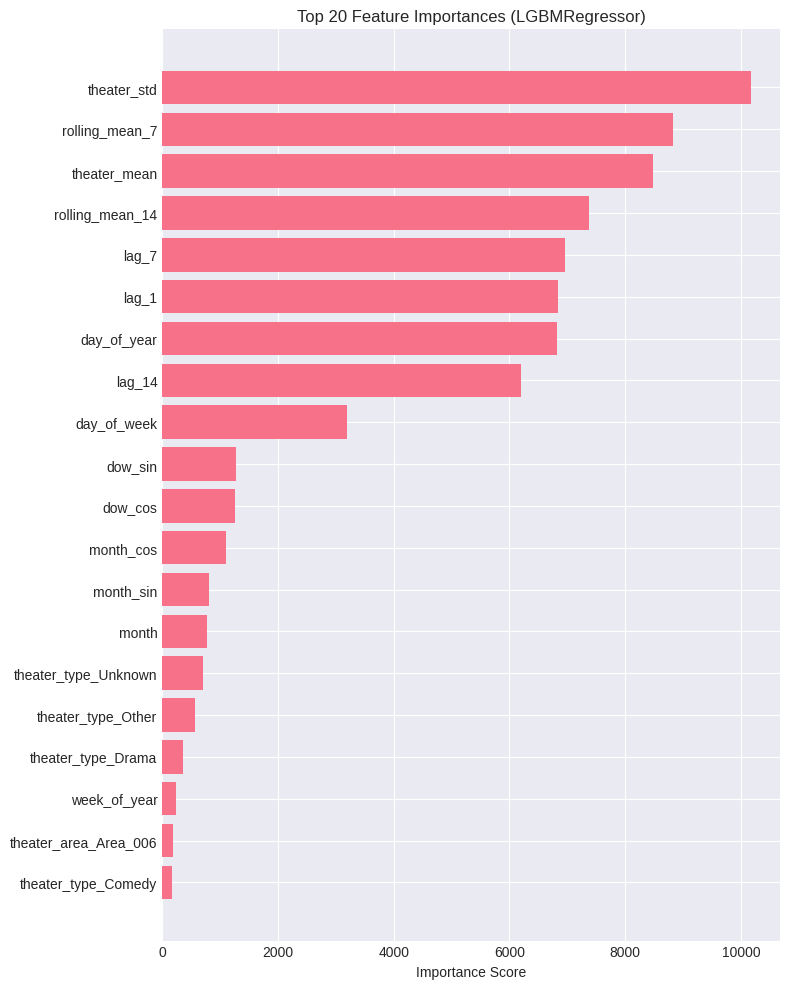

In [21]:
model = best_model
feature_names = X_train.columns

print(f"Showing feature importance for model class: {model.__class__.__name__}")

def get_feature_importance(model):
    model_name = model.__class__.__name__
    if model_name in ["LGBMRegressor", "LGBMClassifier"]:
        return model.feature_importances_

importances = get_feature_importance(model)

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8, 10))
plt.barh(fi_df["Feature"].head(20), fi_df["Importance"].head(20))
plt.gca().invert_yaxis()
plt.title(f"Top 20 Feature Importances ({model.__class__.__name__})")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


# Inference and Submission 

In [22]:
from datetime import datetime

# --- Basic feature preparation ---
submission_format['book_theater_id'] = submission_format['ID'].str.split('_').str[0:2].str.join('_')
submission_format['show_date'] = pd.to_datetime(submission_format['ID'].str.split('_').str[-1])

submission_features = pd.DataFrame({
    'book_theater_id': submission_format['book_theater_id'],
    'show_date': submission_format['show_date']
})

submission_features['day_of_week'] = submission_features['show_date'].dt.dayofweek
submission_features['month'] = submission_features['show_date'].dt.month
submission_features['day_of_year'] = submission_features['show_date'].dt.dayofyear
submission_features['week_of_year'] = submission_features['show_date'].dt.isocalendar().week
submission_features['is_weekend'] = (submission_features['day_of_week'] >= 5).astype(int)

# Cyclical encoding
submission_features['month_sin'] = np.sin(2 * np.pi * submission_features['month'] / 12)
submission_features['month_cos'] = np.cos(2 * np.pi * submission_features['month'] / 12)
submission_features['dow_sin'] = np.sin(2 * np.pi * submission_features['day_of_week'] / 7)
submission_features['dow_cos'] = np.cos(2 * np.pi * submission_features['day_of_week'] / 7)

# Merge external info
if 'book_theater_id' in theater_info.columns:
    submission_features = submission_features.merge(theater_info, on='book_theater_id', how='left')

submission_features = submission_features.merge(theater_stats, on='book_theater_id', how='left')

# Fill missing values
for col in submission_features.columns:
    if submission_features[col].dtype in ['float64', 'int64']:
        submission_features[col] = submission_features[col].fillna(submission_features[col].median())
    else:
        submission_features[col] = submission_features[col].fillna('Unknown')

global_mean = combined_data['audience_count'].mean()
global_median = combined_data['audience_count'].median()

# Create missing lag features
lag_features = ['lag_1', 'lag_7', 'lag_14', 'lag_30']
for lag in lag_features:
    if lag in numerical_features:
        submission_features[lag] = submission_features.get('theater_mean', global_mean).fillna(global_mean)

# Create missing rolling features
rolling_features = ['rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7']
for rf in rolling_features:
    if rf in numerical_features:
        submission_features[rf] = submission_features.get('theater_mean', global_mean).fillna(global_mean)

# Regional mean stats
if 'theater_area' in submission_features.columns and 'theater_area' in combined_data.columns:
    area_avg = combined_data.groupby('theater_area')['audience_count'].mean()
    submission_features['area_avg_attendance'] = submission_features['theater_area'].map(area_avg).fillna(global_mean)

# Check missing features
missing_features = []

for feature in numerical_features:
    if feature not in submission_features.columns:
        submission_features[feature] = global_median
        missing_features.append(feature)

for feature in categorical_features:
    if feature not in submission_features.columns:
        submission_features[feature] = 'Unknown'
        missing_features.append(feature)

# Build final feature matrix
submission_X = submission_features[numerical_features].copy()

# Encode categorical features
if categorical_features and 'encoder' in locals():
    encoded_sub = encoder.transform(submission_features[categorical_features])
    encoded_sub_df = pd.DataFrame(encoded_sub, columns=encoder.get_feature_names_out(categorical_features))
    submission_X = pd.concat([submission_X.reset_index(drop=True),
                              encoded_sub_df.reset_index(drop=True)], axis=1)
    
submission_predictions = best_model.predict(submission_X)

# Post-process predictions
submission_predictions = np.clip(submission_predictions, 0, None)
submission_predictions = np.round(submission_predictions).astype(int)

Q1, Q3 = np.percentile(submission_predictions, [25, 75])
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
submission_predictions = np.clip(submission_predictions, 0, upper_bound)

final_submission = submission_format[['ID']].copy()
final_submission['audience_count'] = submission_predictions

final_submission.to_csv("final_submission.csv", index=False)

print(final_submission.head(10))
print(final_submission['audience_count'].describe())

                      ID  audience_count
0  book_00001_2024-03-01            46.0
1  book_00001_2024-03-02            58.0
2  book_00001_2024-03-03            60.0
3  book_00001_2024-03-04            45.0
4  book_00001_2024-03-06            37.0
5  book_00001_2024-03-07            46.0
6  book_00001_2024-03-08            46.0
7  book_00001_2024-03-09            59.0
8  book_00001_2024-03-10            60.0
9  book_00001_2024-03-11            46.0
count    38062.000000
mean        41.748516
std         21.741647
min          3.000000
25%         24.000000
50%         38.000000
75%         56.000000
max        121.000000
Name: audience_count, dtype: float64
